# Week 5: Initialization Analysis — Xavier vs He vs Default
## Weight Magnitude, Distribution Statistics, and the Lens Power Metric

**Project:** Pattern Interpretability in Neural Networks — Log-Normal Weight Distributions

---

### What This Notebook Does

Three experiments following mentor guidance:

**Experiment 1 — Init Comparison:** Train D×W configurations with Xavier, He, and PyTorch Default (Kaiming Uniform) init. Track final accuracy and weight statistics (A, μ, σ) per layer.

**Experiment 2 — Weight Magnitude Across Depth/Width:** For each trained model, extract layer-by-layer weight statistics: mean absolute magnitude (A), mean (μ), standard deviation (σ), and the log-normal fit quality. See how these change with depth, width, and init method — and whether they predict collapse.

**Experiment 3 — The Lens Power Metric:** Each layer's weight matrix acts like an optical lens. We define **Lens Power** via the singular value decomposition of each weight matrix. A functional layer has balanced singular values (good focus); a collapsed layer concentrates all power in one direction (aberration). We compute:
- `Stable Rank = ||W||_F² / ||W||_op²` = ratio of Frobenius norm² to spectral norm² — a soft measure of how many directions the layer uses
- `Lens Power = σ_mean / σ_max` — how uniformly the layer distributes its transformation (1 = perfect lens, →0 = collapsed)
- `Condition Number = σ_max / σ_min` — focal precision (low = sharp, high = aberrated/degenerate)

### Literature Context
- **Glorot & Bengio (2010):** Xavier init targets Var[W] = 2/(fan_in + fan_out) to keep activation variance constant through depth
- **He et al. (2015):** He init targets Var[W] = 2/fan_in, correcting for ReLU halving the variance
- **PyTorch default:** Kaiming Uniform with a=√5, which is a fan-in scaled uniform — slightly different from He Normal
- **Key insight:** At collapse, weights either explode (‖W‖→∞) or die (‖W‖→0 or rank-1), both of which destroy the lens analogy

In [2]:
# ── 0. IMPORTS ────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings, json, os
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from scipy import stats as scipy_stats
from scipy.stats import lognorm

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available(): print(f'GPU: {torch.cuda.get_device_name(0)}')

torch.manual_seed(42)
np.random.seed(42)

Device: cpu


In [3]:
# ── 1. CONFIGURATION ──────────────────────────────────────────────────────────

# Same architectures as previous weeks — spans functional → collapse boundary
DEPTHS  = [10, 22, 24, 26]   # D10=clearly functional, D22=near boundary, D24/26=collapse zone
WIDTHS  = [64, 128, 256, 512]

EPOCHS  = 10
BATCH   = 256
LR      = 1e-3

# Three initialization strategies to compare
INIT_METHODS = ['default', 'xavier', 'he']   # PyTorch default, Xavier Normal, He Normal

INIT_LABELS = {
    'default': 'Default (Kaiming Uniform)',
    'xavier' : 'Xavier Normal (Glorot 2010)',
    'he'     : 'He Normal (Kaiming 2015)',
}

print('Config loaded.')
print(f'Total training runs: {len(DEPTHS)} depths × {len(WIDTHS)} widths × {len(INIT_METHODS)} inits = {len(DEPTHS)*len(WIDTHS)*len(INIT_METHODS)}')

Config loaded.
Total training runs: 4 depths × 4 widths × 3 inits = 48


In [4]:
# ── 2. DATA ───────────────────────────────────────────────────────────────────

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])
train_ds = datasets.MNIST('./data', train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST('./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f'Data loaded: {len(train_ds)} train, {len(test_ds)} test')

100%|██████████████████████████████████████| 9.91M/9.91M [00:05<00:00, 1.77MB/s]
100%|██████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 1.54MB/s]
100%|██████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.04MB/s]
100%|██████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 5.37MB/s]

Data loaded: 60000 train, 10000 test


In [5]:
# ── 3. MODEL + INIT ───────────────────────────────────────────────────────────

class DynamicMLP(nn.Module):
    def __init__(self, depth, width, input_dim=784, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, width), nn.ReLU()]
        for _ in range(depth - 2):
            layers.append(nn.Linear(width, width))
            layers.append(nn.ReLU())
        layers.append(nn.Linear(width, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x): return self.net(x)

    def get_linear_layers(self):
        """Return list of all Linear modules."""
        return [m for m in self.net if isinstance(m, nn.Linear)]


def apply_init(model, method):
    """Apply initialization to all Linear layers of a model."""
    for m in model.modules():
        if isinstance(m, nn.Linear):
            if method == 'xavier':
                nn.init.xavier_normal_(m.weight)         # Glorot 2010: var = 2/(fan_in+fan_out)
                nn.init.zeros_(m.bias)
            elif method == 'he':
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')  # He 2015: var = 2/fan_in
                nn.init.zeros_(m.bias)
            # 'default': leave PyTorch default (kaiming_uniform_ with a=sqrt(5))
    return model


def get_test_accuracy(model):
    model.eval()
    correct = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            correct += (model(xb).argmax(1) == yb).sum().item()
    return 100.0 * correct / len(test_ds)


print('Architecture and init functions defined.')

Architecture and init functions defined.


In [6]:
# ── 4. WEIGHT STATISTICS EXTRACTION ──────────────────────────────────────────

def weight_stats_per_layer(model):
    """
    For each Linear layer, compute:
      A       = mean absolute weight (amplitude)
      mu      = mean weight
      sigma   = std of weights
      lognorm_mu, lognorm_sigma = fit of log-normal to |W| distribution
      lognorm_r2               = R² of log-normal fit
    """
    records = []
    linear_layers = model.get_linear_layers()
    for i, layer in enumerate(linear_layers):
        w = layer.weight.detach().cpu().numpy().flatten()
        abs_w = np.abs(w)

        A     = float(abs_w.mean())
        mu    = float(w.mean())
        sigma = float(w.std())

        # Fit log-normal to |W| (the distribution of absolute weight values)
        # This tests the "ideal state" hypothesis from the project
        abs_w_pos = abs_w[abs_w > 1e-10]
        if len(abs_w_pos) > 10:
            log_w = np.log(abs_w_pos)
            ln_mu    = float(log_w.mean())
            ln_sigma = float(log_w.std())
            # R² of normal fit to log(|W|) — quantifies log-normality
            _, (slope, intercept, r) = scipy_stats.probplot(log_w, dist='norm', fit=True)
            ln_r2 = float(r**2)
        else:
            ln_mu, ln_sigma, ln_r2 = np.nan, np.nan, np.nan

        records.append({
            'layer_idx'  : i,
            'layer_shape': tuple(layer.weight.shape),
            'A'          : A,
            'mu'         : mu,
            'sigma'      : sigma,
            'ln_mu'      : ln_mu,
            'ln_sigma'   : ln_sigma,
            'ln_r2'      : ln_r2,
        })
    return records


def lens_power_per_layer(model):
    """
    For each Linear layer, compute the 'Lens Power' metrics via SVD of weight matrix W:

    ANALOGY: Each layer is a lens that focuses/transforms the input space.
      - Singular values σ_i of W describe the 'refractive power' in each direction.
      - A perfect lens: all σ_i equal (uniform focus in all directions)
      - A collapsed lens: one dominant σ (all light bent the same way = no discrimination)
      - A dead lens: all σ → 0 (absorbs everything, passes nothing)

    Metrics:
      stable_rank      = ||W||_F^2 / ||W||_op^2  = sum(σ²) / max(σ)²
                         → how many 'effective dimensions' the lens uses
      lens_power       = mean(σ) / max(σ)
                         → uniformity of focus (1=perfect, 0=degenerate)
      condition_number = max(σ) / min(σ+ε)
                         → precision (low=sharp, high=aberrated)
      spectral_norm    = max(σ)  → overall amplification
      frobenius_norm   = ||W||_F → total energy
    """
    records = []
    linear_layers = model.get_linear_layers()
    for i, layer in enumerate(linear_layers):
        W = layer.weight.detach().cpu().float().numpy()
        try:
            # Full SVD — singular values in descending order
            svs = np.linalg.svd(W, compute_uv=False)
            svs = svs[svs > 0]
            if len(svs) == 0:
                raise ValueError('No positive singular values')

            spec_norm    = float(svs[0])
            frob_norm    = float(np.linalg.norm(W, 'fro'))
            stable_rank  = float((frob_norm**2) / (spec_norm**2 + 1e-10))
            lens_power   = float(svs.mean() / svs[0])         # [0,1], 1=perfect
            cond_number  = float(svs[0] / (svs[-1] + 1e-10))  # large = ill-conditioned
            sv_entropy   = float(-np.sum((svs/svs.sum()) * np.log(svs/svs.sum() + 1e-10)))

        except Exception as e:
            spec_norm = frob_norm = stable_rank = lens_power = cond_number = sv_entropy = np.nan

        records.append({
            'layer_idx'    : i,
            'layer_shape'  : tuple(W.shape),
            'spectral_norm': spec_norm,
            'frob_norm'    : frob_norm,
            'stable_rank'  : stable_rank,
            'lens_power'   : lens_power,
            'cond_number'  : cond_number,
            'sv_entropy'   : sv_entropy,
        })
    return records


print('Weight statistics and Lens Power functions defined.')

Weight statistics and Lens Power functions defined.


In [7]:
# ── 5. TRAINING LOOP ──────────────────────────────────────────────────────────

def train_and_collect(depth, width, init_method):
    model = DynamicMLP(depth=depth, width=width).to(DEVICE)
    apply_init(model, init_method)

    # Capture stats BEFORE training
    wstats_before = weight_stats_per_layer(model)
    lstats_before = lens_power_per_layer(model)

    # Train
    optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    acc_curve = []
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            criterion(model(xb), yb).backward()
            optimizer.step()
        scheduler.step()
        acc_curve.append(get_test_accuracy(model))

    final_acc = acc_curve[-1]
    best_acc  = max(acc_curve)
    status    = 'FUNCTIONAL' if final_acc > 70 else ('NEAR-COLLAPSE' if final_acc >= 20 else 'COLLAPSED')

    # Capture stats AFTER training
    wstats_after  = weight_stats_per_layer(model)
    lstats_after  = lens_power_per_layer(model)

    print(f'  D{depth:2d} W{width:3d} [{init_method:7s}]: {final_acc:.2f}% (best {best_acc:.2f}%) [{status}]')

    return {
        'depth'         : depth,
        'width'         : width,
        'init'          : init_method,
        'final_acc'     : final_acc,
        'best_acc'      : best_acc,
        'status'        : status,
        'acc_curve'     : acc_curve,
        'wstats_before' : wstats_before,
        'wstats_after'  : wstats_after,
        'lstats_before' : lstats_before,
        'lstats_after'  : lstats_after,
    }


print('Training function defined. Starting runs...')

Training function defined. Starting runs...


In [8]:
# ── 6. RUN ALL EXPERIMENTS ────────────────────────────────────────────────────
# Total: 4 depths × 4 widths × 3 inits = 48 runs
# Each ~30s on GPU → ~25 min total

import time
all_results = []
total = len(DEPTHS) * len(WIDTHS) * len(INIT_METHODS)
done  = 0
t_start = time.time()

for depth in DEPTHS:
    for width in WIDTHS:
        for init in INIT_METHODS:
            res = train_and_collect(depth, width, init)
            all_results.append(res)
            done += 1
            elapsed = time.time() - t_start
            eta = (elapsed / done) * (total - done)
            print(f'  [{done}/{total}] elapsed={elapsed/60:.1f}m  ETA={eta/60:.1f}m')

print(f'\nAll {total} runs complete in {(time.time()-t_start)/60:.1f} minutes.')

  D10 W 64 [default]: 95.71% (best 95.96%) [FUNCTIONAL]
  [1/48] elapsed=0.7m  ETA=32.1m
  D10 W 64 [xavier ]: 97.25% (best 97.47%) [FUNCTIONAL]
  [2/48] elapsed=1.3m  ETA=31.0m
  D10 W 64 [he     ]: 97.00% (best 97.05%) [FUNCTIONAL]
  [3/48] elapsed=2.0m  ETA=30.1m
  D10 W128 [default]: 97.29% (best 97.36%) [FUNCTIONAL]
  [4/48] elapsed=2.7m  ETA=29.7m
  D10 W128 [xavier ]: 97.63% (best 97.81%) [FUNCTIONAL]
  [5/48] elapsed=3.4m  ETA=29.2m
  D10 W128 [he     ]: 97.57% (best 97.85%) [FUNCTIONAL]
  [6/48] elapsed=4.1m  ETA=28.8m
  D10 W256 [default]: 97.70% (best 97.70%) [FUNCTIONAL]
  [7/48] elapsed=4.8m  ETA=28.2m
  D10 W256 [xavier ]: 98.13% (best 98.13%) [FUNCTIONAL]
  [8/48] elapsed=5.5m  ETA=27.5m
  D10 W256 [he     ]: 97.86% (best 98.08%) [FUNCTIONAL]
  [9/48] elapsed=6.2m  ETA=26.8m
  D10 W512 [default]: 97.49% (best 97.81%) [FUNCTIONAL]
  [10/48] elapsed=7.1m  ETA=26.9m
  D10 W512 [xavier ]: 97.73% (best 98.30%) [FUNCTIONAL]
  [11/48] elapsed=8.0m  ETA=26.8m
  D10 W512 [he     

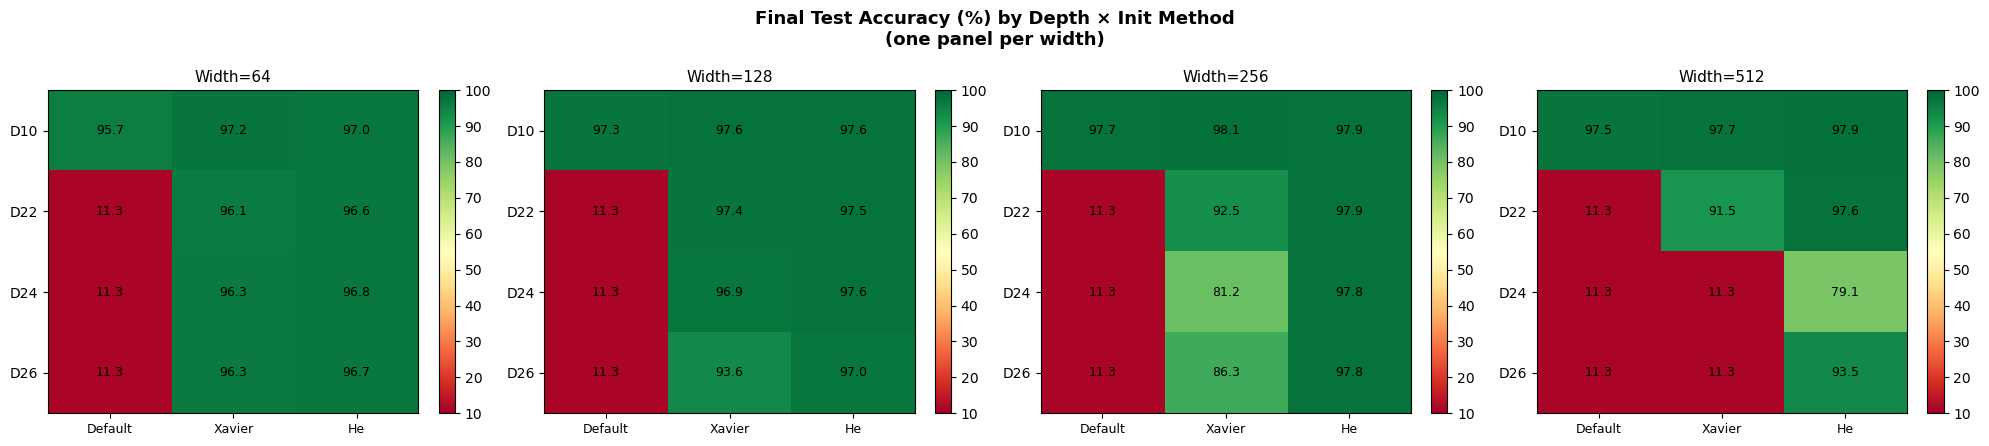


Accuracy Table:
 Depth  Width    Init  FinalAcc%  BestAcc%     Status
    10     64 default      95.71     95.96 FUNCTIONAL
    10     64      he      97.00     97.05 FUNCTIONAL
    10     64  xavier      97.25     97.47 FUNCTIONAL
    22     64 default      11.35     11.35  COLLAPSED
    22     64      he      96.56     96.65 FUNCTIONAL
    22     64  xavier      96.10     96.22 FUNCTIONAL
    24     64 default      11.35     11.35  COLLAPSED
    24     64      he      96.78     96.78 FUNCTIONAL
    24     64  xavier      96.34     96.41 FUNCTIONAL
    26     64 default      11.35     11.35  COLLAPSED
    26     64      he      96.67     96.67 FUNCTIONAL
    26     64  xavier      96.31     96.31 FUNCTIONAL
    10    128 default      97.29     97.36 FUNCTIONAL
    10    128      he      97.57     97.85 FUNCTIONAL
    10    128  xavier      97.63     97.81 FUNCTIONAL
    22    128 default      11.35     11.35  COLLAPSED
    22    128      he      97.55     97.55 FUNCTIONAL
    22    1

In [9]:
# ── 7. PLOT 1: ACCURACY HEATMAP — INIT METHOD vs DEPTH (per width) ────────────

fig, axes = plt.subplots(1, len(WIDTHS), figsize=(5*len(WIDTHS), 4.5))
fig.suptitle('Final Test Accuracy (%) by Depth × Init Method\n(one panel per width)',
             fontsize=13, fontweight='bold')

cmap = plt.cm.RdYlGn
for wi, width in enumerate(WIDTHS):
    ax = axes[wi]
    matrix = np.zeros((len(DEPTHS), len(INIT_METHODS)))
    for di, d in enumerate(DEPTHS):
        for ii, init in enumerate(INIT_METHODS):
            r = next(x for x in all_results if x['depth']==d and x['width']==width and x['init']==init)
            matrix[di, ii] = r['final_acc']
    im = ax.imshow(matrix, cmap=cmap, vmin=10, vmax=100, aspect='auto')
    ax.set_xticks(range(len(INIT_METHODS)))
    ax.set_xticklabels(['Default','Xavier','He'], fontsize=9)
    ax.set_yticks(range(len(DEPTHS)))
    ax.set_yticklabels([f'D{d}' for d in DEPTHS])
    ax.set_title(f'Width={width}', fontsize=11)
    for di in range(len(DEPTHS)):
        for ii in range(len(INIT_METHODS)):
            ax.text(ii, di, f'{matrix[di,ii]:.1f}', ha='center', va='center', fontsize=9,
                    color='black')
    plt.colorbar(im, ax=ax, fraction=0.04)

plt.tight_layout()
plt.savefig('exp1_accuracy_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Table
acc_rows = []
for r in all_results:
    acc_rows.append({'Depth':r['depth'],'Width':r['width'],'Init':r['init'],
                     'FinalAcc%':round(r['final_acc'],2),'BestAcc%':round(r['best_acc'],2),'Status':r['status']})
df_acc = pd.DataFrame(acc_rows).sort_values(['Width','Depth','Init'])
print('\nAccuracy Table:')
print(df_acc.to_string(index=False))
df_acc.to_csv('exp1_accuracy.csv', index=False)

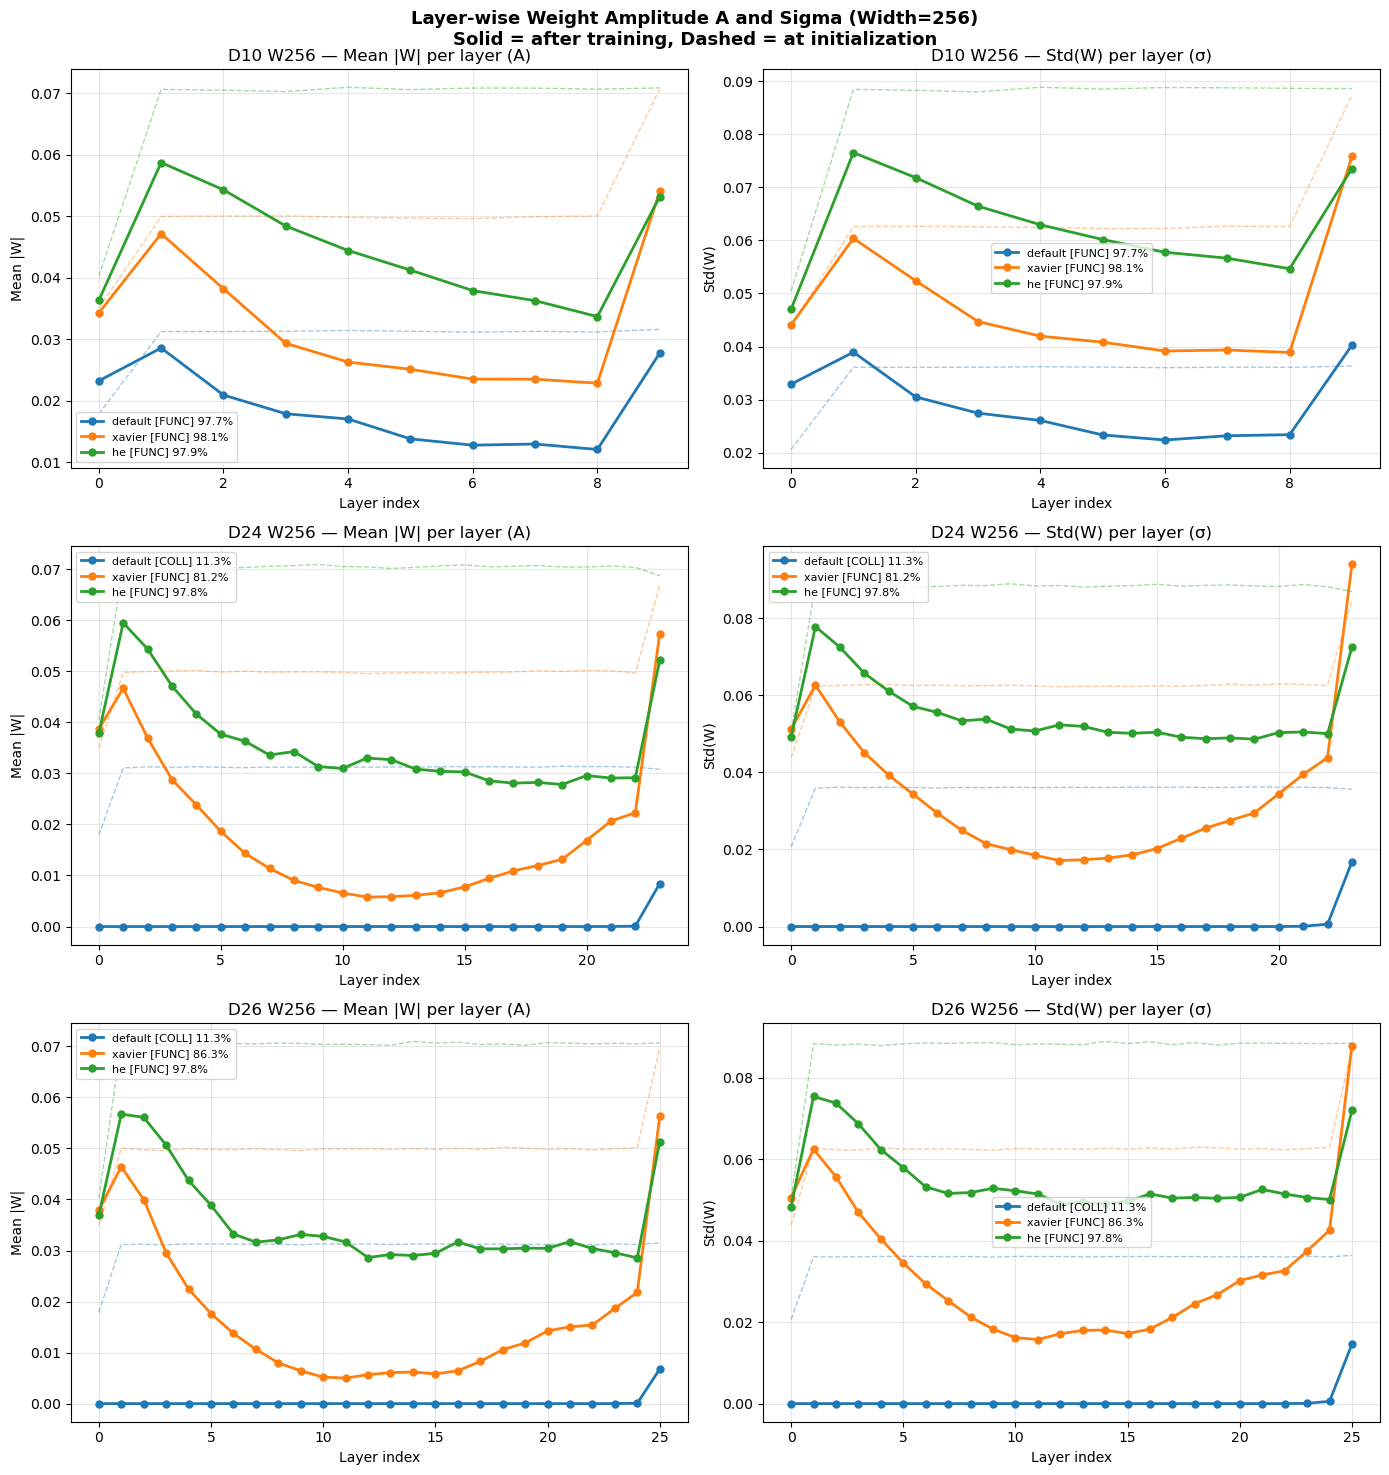


Weight Statistics Table (after training, selected depths):
 Depth  Width    Init     Status  Layer  A_after  sigma_after  lognorm_r2
    10    256 default FUNCTIONAL      0 0.023223     0.032905      0.9424
    10    256 default FUNCTIONAL      1 0.028563     0.038937      0.6379
    10    256 default FUNCTIONAL      2 0.020918     0.030507      0.6443
    10    256 default FUNCTIONAL      3 0.017871     0.027452      0.6848
    10    256 default FUNCTIONAL      4 0.017020     0.026072      0.6798
    10    256 default FUNCTIONAL      5 0.013791     0.023341      0.7340
    10    256 default FUNCTIONAL      6 0.012763     0.022393      0.7460
    10    256 default FUNCTIONAL      7 0.012952     0.023191      0.7630
    10    256 default FUNCTIONAL      8 0.012065     0.023394      0.7876
    10    256 default FUNCTIONAL      9 0.027724     0.040260      0.6833
    10    256  xavier FUNCTIONAL      0 0.034266     0.044088      0.9094
    10    256  xavier FUNCTIONAL      1 0.047135    

In [10]:
# ── 8. PLOT 2: WEIGHT MAGNITUDE (A, σ) ACROSS LAYERS — BEFORE vs AFTER ────────
# Show how init shapes A and σ, and how training changes it
# Focus on one depth per regime: D10 (functional), D24 (boundary), D26 (collapse)

FOCAL_DEPTHS = [10, 24, 26]
FOCAL_WIDTH  = 256   # fix one width for clarity

init_colors = {'default': '#1f77b4', 'xavier': '#ff7f0e', 'he': '#2ca02c'}

fig, axes = plt.subplots(len(FOCAL_DEPTHS), 2, figsize=(14, 5*len(FOCAL_DEPTHS)))
fig.suptitle(f'Layer-wise Weight Amplitude A and Sigma (Width={FOCAL_WIDTH})\n'
             'Solid = after training, Dashed = at initialization',
             fontsize=13, fontweight='bold')

wstats_table = []

for row, depth in enumerate(FOCAL_DEPTHS):
    ax_A  = axes[row][0]
    ax_sg = axes[row][1]
    ax_A.set_title(f'D{depth} W{FOCAL_WIDTH} — Mean |W| per layer (A)')
    ax_sg.set_title(f'D{depth} W{FOCAL_WIDTH} — Std(W) per layer (σ)')

    for init in INIT_METHODS:
        res = next(x for x in all_results
                   if x['depth']==depth and x['width']==FOCAL_WIDTH and x['init']==init)
        c   = init_colors[init]
        lbl = f"{init} [{res['status'][:4]}] {res['final_acc']:.1f}%"

        idx_b  = [r['layer_idx'] for r in res['wstats_before']]
        A_b    = [r['A']     for r in res['wstats_before']]
        sg_b   = [r['sigma'] for r in res['wstats_before']]
        A_a    = [r['A']     for r in res['wstats_after']]
        sg_a   = [r['sigma'] for r in res['wstats_after']]

        ax_A.plot(idx_b, A_a,  '-o', color=c, label=lbl, linewidth=2, markersize=5)
        ax_A.plot(idx_b, A_b,  '--', color=c, alpha=0.4, linewidth=1)
        ax_sg.plot(idx_b, sg_a, '-o', color=c, label=lbl, linewidth=2, markersize=5)
        ax_sg.plot(idx_b, sg_b, '--', color=c, alpha=0.4, linewidth=1)

        # Collect for table
        for r_b, r_a in zip(res['wstats_before'], res['wstats_after']):
            wstats_table.append({
                'Depth':depth,'Width':FOCAL_WIDTH,'Init':init,'Status':res['status'],
                'Layer':r_b['layer_idx'],
                'A_before':round(r_b['A'],6), 'A_after':round(r_a['A'],6),
                'mu_before':round(r_b['mu'],6),'mu_after':round(r_a['mu'],6),
                'sigma_before':round(r_b['sigma'],6),'sigma_after':round(r_a['sigma'],6),
                'ln_mu_after':round(r_a['ln_mu'],4) if not np.isnan(r_a['ln_mu']) else None,
                'ln_sigma_after':round(r_a['ln_sigma'],4) if not np.isnan(r_a['ln_sigma']) else None,
                'lognorm_r2':round(r_a['ln_r2'],4) if not np.isnan(r_a['ln_r2']) else None,
            })

    ax_A.set_xlabel('Layer index'); ax_A.set_ylabel('Mean |W|')
    ax_sg.set_xlabel('Layer index'); ax_sg.set_ylabel('Std(W)')
    ax_A.legend(fontsize=8); ax_sg.legend(fontsize=8)
    ax_A.grid(True, alpha=0.3); ax_sg.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_weight_magnitude_layers.png', dpi=150, bbox_inches='tight')
plt.show()

df_wstats = pd.DataFrame(wstats_table)
print('\nWeight Statistics Table (after training, selected depths):')
print(df_wstats[['Depth','Width','Init','Status','Layer','A_after','sigma_after','lognorm_r2']].to_string(index=False))
df_wstats.to_csv('exp2_weight_stats.csv', index=False)

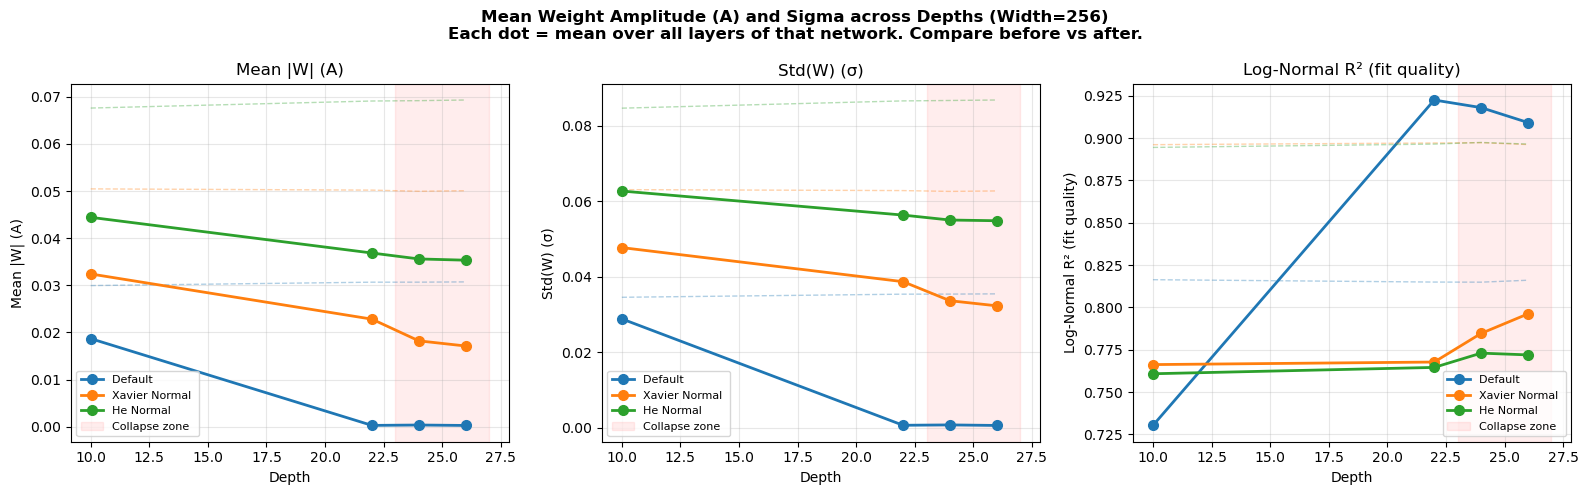


Mean weight metric vs depth table:
Init              default       he   xavier
Depth Status                               
10    FUNCTIONAL  0.01869  0.04443  0.03242
22    COLLAPSED   0.00028      NaN      NaN
      FUNCTIONAL      NaN  0.03686  0.02282
24    COLLAPSED   0.00035      NaN      NaN
      FUNCTIONAL      NaN  0.03560  0.01822
26    COLLAPSED   0.00026      NaN      NaN
      FUNCTIONAL      NaN  0.03533  0.01713


In [11]:
# ── 9. PLOT 3: A vs DEPTH — how weight amplitude scales with depth per init ───
# For each init method, plot the MEAN A across all layers, across depths
# This shows whether deeper networks maintain or lose amplitude

FOCAL_W = 256

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Mean Weight Amplitude (A) and Sigma across Depths (Width={FOCAL_W})\n'
             'Each dot = mean over all layers of that network. Compare before vs after.',
             fontsize=12, fontweight='bold')

metrics_to_plot = [('A', 'Mean |W| (A)'), ('sigma', 'Std(W) (σ)'), ('ln_r2', 'Log-Normal R² (fit quality)')]

depth_scatter_table = []

for ax_i, (metric, ylabel) in enumerate(metrics_to_plot):
    ax = axes[ax_i]
    ax.set_title(ylabel)
    ax.set_xlabel('Depth')
    ax.set_ylabel(ylabel)

    for init in INIT_METHODS:
        c = init_colors[init]
        means_after  = []
        means_before = []
        for d in DEPTHS:
            res = next(x for x in all_results if x['depth']==d and x['width']==FOCAL_W and x['init']==init)
            vals_a = [r[metric] for r in res['wstats_after']  if not (isinstance(r[metric], float) and np.isnan(r[metric]))]
            vals_b = [r[metric] for r in res['wstats_before'] if not (isinstance(r[metric], float) and np.isnan(r[metric]))]
            means_after.append(np.mean(vals_a) if vals_a else np.nan)
            means_before.append(np.mean(vals_b) if vals_b else np.nan)
            depth_scatter_table.append({'Depth':d,'Width':FOCAL_W,'Init':init,
                                        'Metric':metric,
                                        'Value_after':round(float(np.mean(vals_a)),6) if vals_a else None,
                                        'Value_before':round(float(np.mean(vals_b)),6) if vals_b else None,
                                        'Status':res['status']})
        ax.plot(DEPTHS, means_after,  '-o', color=c, label=INIT_LABELS[init].split('(')[0], lw=2, ms=7)
        ax.plot(DEPTHS, means_before, '--', color=c, alpha=0.35, lw=1)

    # Shade collapse zone
    ax.axvspan(23, 27, alpha=0.07, color='red', label='Collapse zone')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_weight_vs_depth.png', dpi=150, bbox_inches='tight')
plt.show()

df_depth = pd.DataFrame(depth_scatter_table)
print('\nMean weight metric vs depth table:')
pivot = df_depth[df_depth['Metric']=='A'].pivot_table(index=['Depth','Status'], columns='Init', values='Value_after')
print(pivot.round(5))
df_depth.to_csv('exp2_weight_vs_depth.csv', index=False)

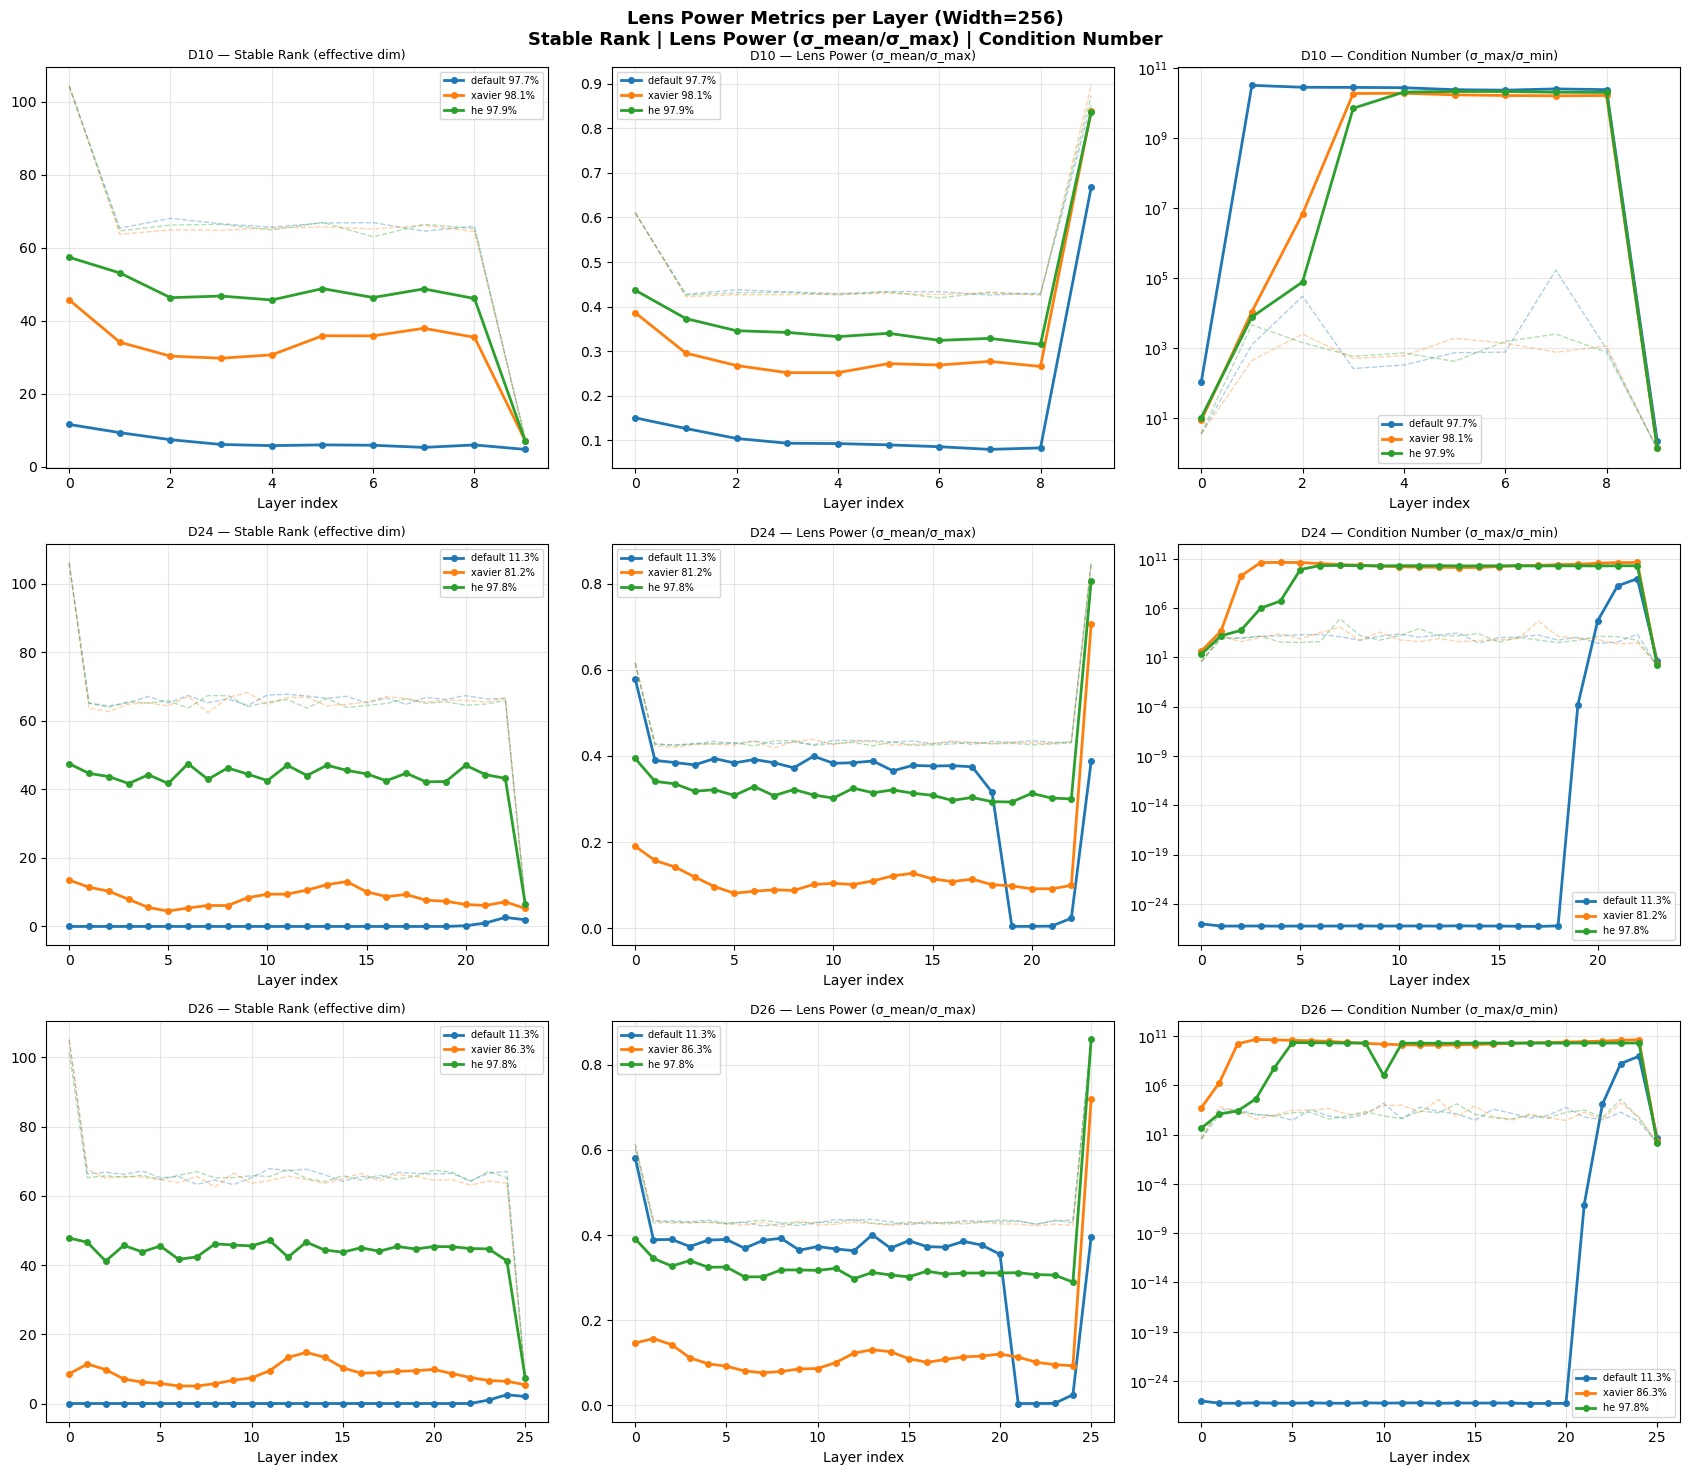


Lens Power Table (after training):
 Depth  Width    Init     Status  Layer  stable_rank  lens_power  cond_number
    10    256 default FUNCTIONAL      0      11.5694      0.1508 1.068700e+02
    10    256 default FUNCTIONAL      1       9.3262      0.1269 3.265804e+10
    10    256 default FUNCTIONAL      2       7.3868      0.1045 2.875245e+10
    10    256 default FUNCTIONAL      3       6.0852      0.0938 2.852129e+10
    10    256 default FUNCTIONAL      4       5.7665      0.0931 2.792639e+10
    10    256 default FUNCTIONAL      5       5.9687      0.0901 2.456152e+10
    10    256 default FUNCTIONAL      6       5.8664      0.0860 2.373254e+10
    10    256 default FUNCTIONAL      7       5.2761      0.0800 2.584765e+10
    10    256 default FUNCTIONAL      8       5.9534      0.0833 2.455624e+10
    10    256 default FUNCTIONAL      9       4.7348      0.6677 2.300000e+00
    10    256  xavier FUNCTIONAL      0      45.6989      0.3866 8.700000e+00
    10    256  xavier FUNCTI

In [12]:
# ── 10. PLOT 4: LENS POWER — layer-by-layer across depths and inits ───────────

fig, axes = plt.subplots(len(FOCAL_DEPTHS), 3, figsize=(17, 5*len(FOCAL_DEPTHS)))
fig.suptitle(f'Lens Power Metrics per Layer (Width={FOCAL_WIDTH})\n'
             'Stable Rank | Lens Power (σ_mean/σ_max) | Condition Number',
             fontsize=13, fontweight='bold')

lens_table = []

for row, depth in enumerate(FOCAL_DEPTHS):
    for col, (metric, label, log_scale) in enumerate([
        ('stable_rank',   'Stable Rank (effective dim)',   False),
        ('lens_power',    'Lens Power (σ_mean/σ_max)',    False),
        ('cond_number',   'Condition Number (σ_max/σ_min)', True),
    ]):
        ax = axes[row][col]
        ax.set_title(f'D{depth} — {label}', fontsize=9)
        ax.set_xlabel('Layer index')

        for init in INIT_METHODS:
            res = next(x for x in all_results
                       if x['depth']==depth and x['width']==FOCAL_WIDTH and x['init']==init)
            c   = init_colors[init]
            lbl = f"{init} {res['final_acc']:.1f}%"

            idx_a  = [r['layer_idx'] for r in res['lstats_after']]
            vals_a = [r[metric]      for r in res['lstats_after']]
            vals_b = [r[metric]      for r in res['lstats_before']]

            ax.plot(idx_a, vals_a, '-o', color=c, label=lbl, lw=2, ms=4)
            ax.plot(idx_a, vals_b, '--',  color=c, alpha=0.35, lw=1)

            # Collect for table
            for r in res['lstats_after']:
                lens_table.append({
                    'Depth':depth,'Width':FOCAL_WIDTH,'Init':init,'Status':res['status'],
                    'Layer':r['layer_idx'],
                    'spectral_norm':round(r['spectral_norm'],4),
                    'frob_norm':round(r['frob_norm'],4),
                    'stable_rank':round(r['stable_rank'],4),
                    'lens_power':round(r['lens_power'],4),
                    'cond_number':round(r['cond_number'],2),
                    'sv_entropy':round(r['sv_entropy'],4),
                })

        if log_scale:
            ax.set_yscale('log')
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp3_lens_power_layers.png', dpi=150, bbox_inches='tight')
plt.show()

df_lens = pd.DataFrame(lens_table)
print('\nLens Power Table (after training):')
print(df_lens[['Depth','Width','Init','Status','Layer','stable_rank','lens_power','cond_number']].to_string(index=False))
df_lens.to_csv('exp3_lens_power.csv', index=False)

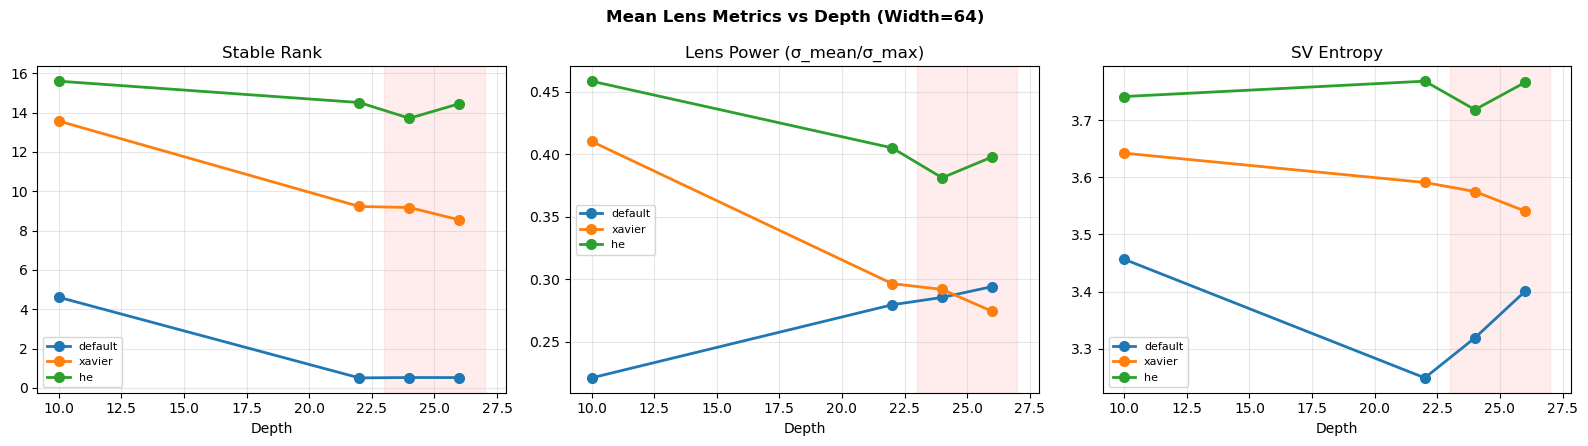

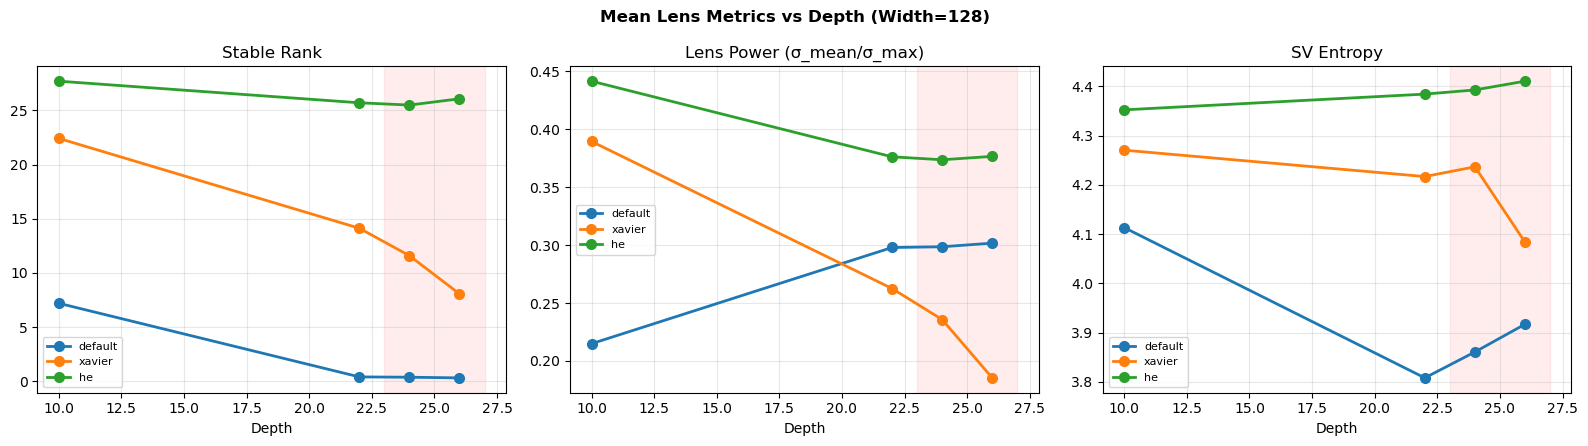

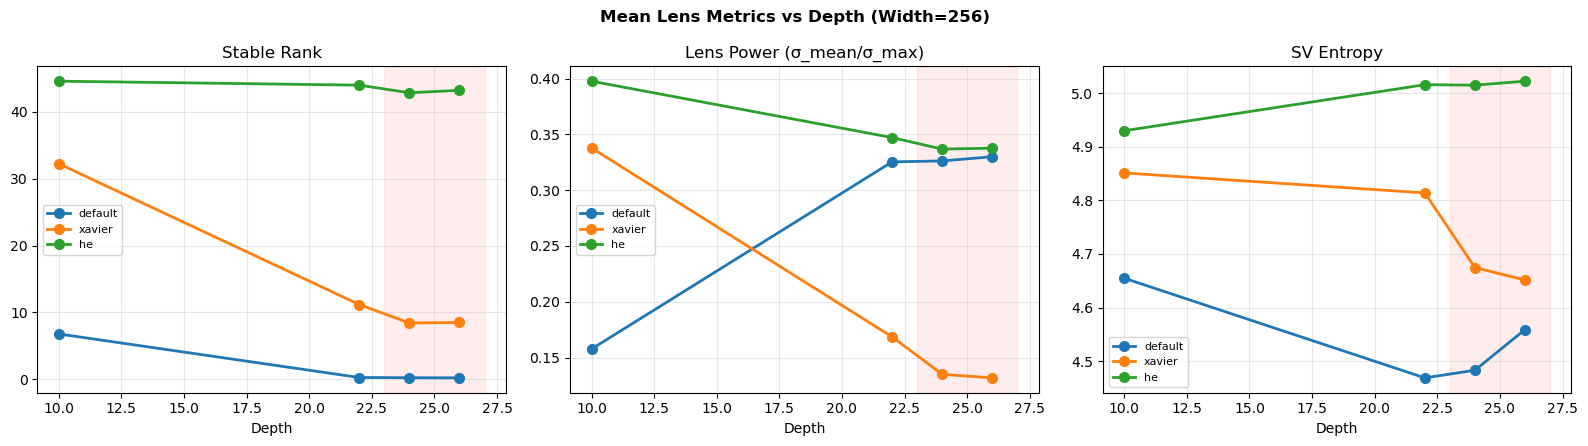

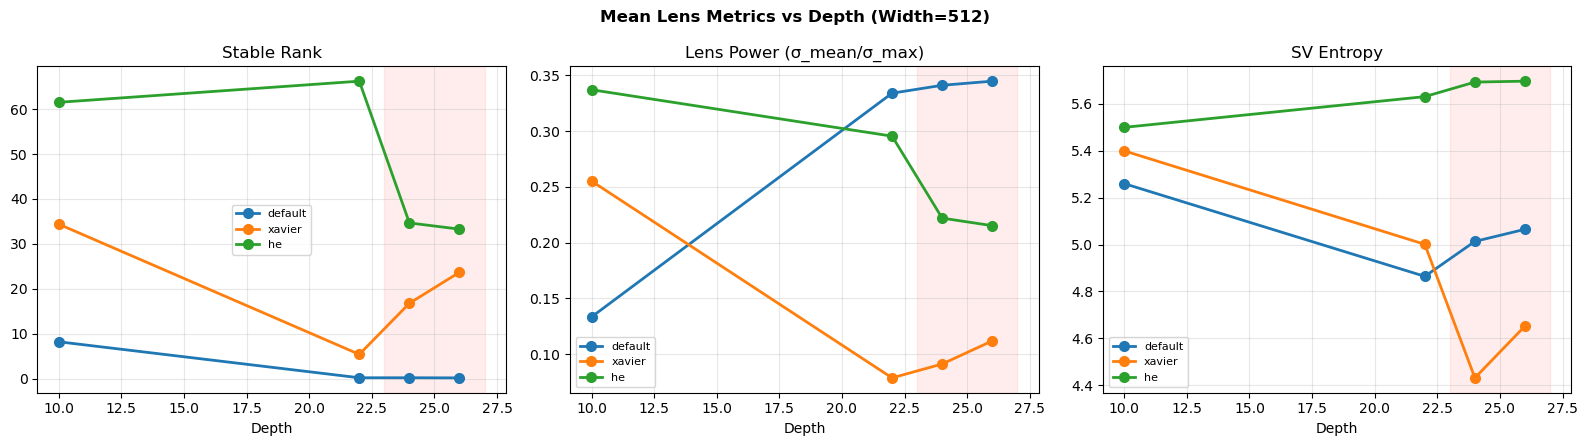


Lens Power Summary vs Depth:
Width     512                
Init  default      he  xavier
Depth                        
10     0.1334  0.3371  0.2552
22     0.3340  0.2954  0.0788
24     0.3410  0.2220  0.0912
26     0.3447  0.2152  0.1119


In [13]:
# ── 11. PLOT 5: LENS POWER vs DEPTH — summary across all configurations ────────
# Mean lens power across all layers for each (depth, width, init)
# Key question: does lens power drop at the collapse boundary?

for width in WIDTHS:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    fig.suptitle(f'Mean Lens Metrics vs Depth (Width={width})', fontsize=12, fontweight='bold')

    lens_summary_rows = []

    for col, (metric, ylabel) in enumerate([
        ('stable_rank', 'Stable Rank'),
        ('lens_power',  'Lens Power (σ_mean/σ_max)'),
        ('sv_entropy',  'SV Entropy'),
    ]):
        ax = axes[col]
        ax.set_title(ylabel)
        ax.set_xlabel('Depth')

        for init in INIT_METHODS:
            c    = init_colors[init]
            vals = []
            for d in DEPTHS:
                res = next(x for x in all_results if x['depth']==d and x['width']==width and x['init']==init)
                layer_vals = [r[metric] for r in res['lstats_after'] if np.isfinite(r[metric])]
                mean_val = np.mean(layer_vals) if layer_vals else np.nan
                vals.append(mean_val)
                lens_summary_rows.append({'Depth':d,'Width':width,'Init':init,
                                          'Status':res['status'],'Metric':metric,
                                          'MeanValue':round(float(mean_val),5) if np.isfinite(mean_val) else None})
            ax.plot(DEPTHS, vals, '-o', color=c, label=init, lw=2, ms=7)

        ax.axvspan(23, 27, alpha=0.07, color='red')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'exp3_lens_vs_depth_W{width}.png', dpi=150, bbox_inches='tight')
    plt.show()

df_lens_summary = pd.DataFrame(lens_summary_rows)
print('\nLens Power Summary vs Depth:')
pivot_lp = df_lens_summary[df_lens_summary['Metric']=='lens_power'].pivot_table(
    index=['Depth'], columns=['Width','Init'], values='MeanValue')
print(pivot_lp.round(4).to_string())
df_lens_summary.to_csv('exp3_lens_summary.csv', index=False)

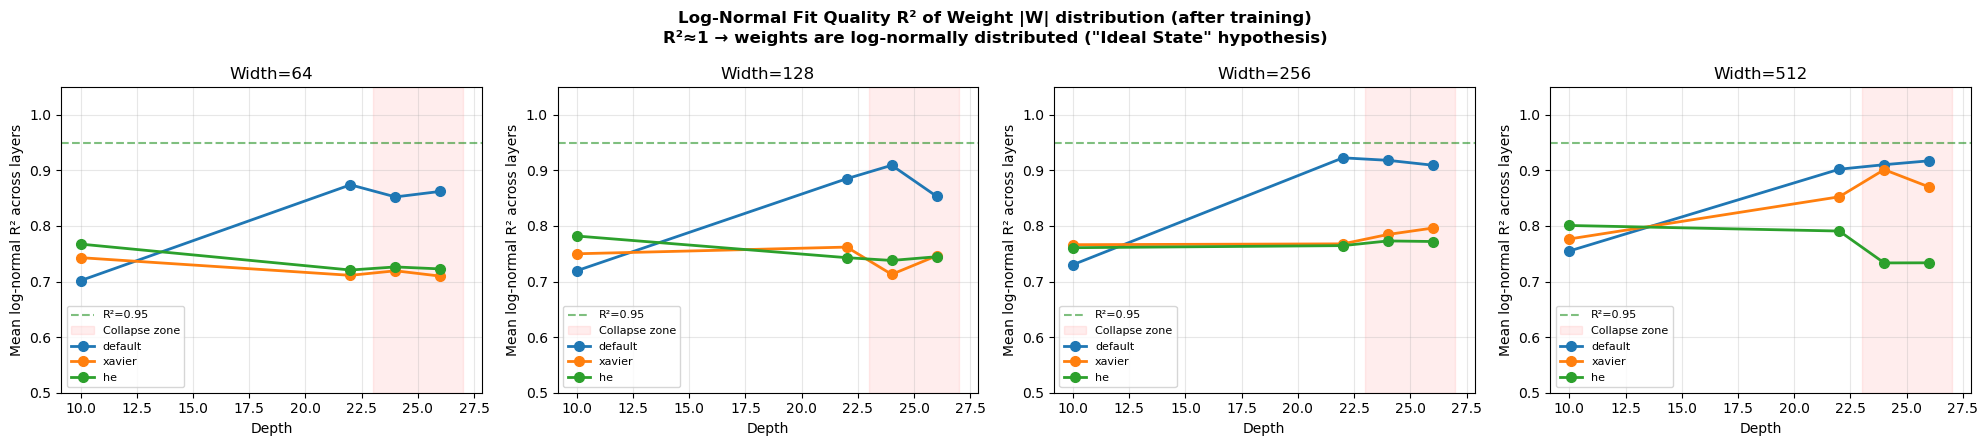


Log-Normal R² Table:
Width     64                    128                   256                   512              
Init  default     he xavier default     he xavier default     he xavier default     he xavier
Depth                                                                                        
10      0.702  0.767  0.743   0.719  0.782  0.750   0.730  0.761  0.766   0.755  0.801  0.776
22      0.874  0.721  0.711   0.885  0.743  0.762   0.922  0.765  0.768   0.902  0.791  0.852
24      0.852  0.726  0.719   0.909  0.738  0.713   0.918  0.773  0.785   0.910  0.734  0.901
26      0.862  0.723  0.710   0.853  0.745  0.746   0.909  0.772  0.796   0.917  0.734  0.870


In [14]:
# ── 12. PLOT 6: LOG-NORMAL FIT QUALITY (R²) — does trained weight dist fit lognormal? ─
# This is the core connection to the project: is the "ideal state" of trained functional
# networks characterized by a log-normal weight distribution?

fig, axes = plt.subplots(1, len(WIDTHS), figsize=(5*len(WIDTHS), 4.5))
fig.suptitle('Log-Normal Fit Quality R² of Weight |W| distribution (after training)\n'
             'R²≈1 → weights are log-normally distributed ("Ideal State" hypothesis)',
             fontsize=12, fontweight='bold')

lognorm_table = []

for wi, width in enumerate(WIDTHS):
    ax = axes[wi]
    ax.set_title(f'Width={width}')
    ax.set_xlabel('Depth')
    ax.set_ylabel('Mean log-normal R² across layers')
    ax.axhline(0.95, color='green', ls='--', alpha=0.5, label='R²=0.95')
    ax.axvspan(23, 27, alpha=0.07, color='red', label='Collapse zone')

    for init in INIT_METHODS:
        c    = init_colors[init]
        vals = []
        for d in DEPTHS:
            res = next(x for x in all_results if x['depth']==d and x['width']==width and x['init']==init)
            r2s = [r['ln_r2'] for r in res['wstats_after'] if r['ln_r2'] is not None and not np.isnan(r['ln_r2'])]
            mean_r2 = np.mean(r2s) if r2s else np.nan
            vals.append(mean_r2)
            lognorm_table.append({'Depth':d,'Width':width,'Init':init,'Status':res['status'],
                                  'MeanLognormR2':round(float(mean_r2),4) if np.isfinite(mean_r2) else None})
        ax.plot(DEPTHS, vals, '-o', color=c, label=init, lw=2, ms=7)

    ax.set_ylim([0.5, 1.05])
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exp2_lognorm_r2.png', dpi=150, bbox_inches='tight')
plt.show()

df_lognorm = pd.DataFrame(lognorm_table)
print('\nLog-Normal R² Table:')
print(df_lognorm.pivot_table(index=['Depth'], columns=['Width','Init'],
                              values='MeanLognormR2').round(3).to_string())
df_lognorm.to_csv('exp2_lognorm_r2.csv', index=False)

In [15]:
# ── 13. COMPILE ALL RESULTS ───────────────────────────────────────────────────

print('\n' + '█'*80)
print('COMPILED RESULTS — WEEK 5: INITIALIZATION & LENS POWER ANALYSIS')
print('█'*80)

print('\n[1] ACCURACY BY INIT METHOD, DEPTH, WIDTH')
print('-'*70)
print(df_acc.pivot_table(index=['Depth','Width'], columns='Init', values='FinalAcc%').round(2).to_string())

print('\n[2] MEAN WEIGHT AMPLITUDE (A) AFTER TRAINING — by init, depth (W=256)')
print('-'*70)
df_A_pivot = df_depth[df_depth['Metric']=='A'].pivot_table(
    index=['Depth','Status'], columns='Init', values='Value_after').round(5)
print(df_A_pivot.to_string())

print('\n[3] MEAN SIGMA AFTER TRAINING — by init, depth (W=256)')
print('-'*70)
df_sg_pivot = df_depth[df_depth['Metric']=='sigma'].pivot_table(
    index=['Depth','Status'], columns='Init', values='Value_after').round(5)
print(df_sg_pivot.to_string())

print('\n[4] LOG-NORMAL FIT QUALITY R² — mean across layers (measures "ideal state" proximity)')
print('-'*70)
print(df_lognorm.pivot_table(index=['Depth','Width'], columns='Init',
                              values='MeanLognormR2').round(3).to_string())

print('\n[5] LENS POWER (σ_mean/σ_max) — mean across layers')
print('Key: 1.0 = uniform focus (healthy), →0 = degenerate/collapsed lens')
print('-'*70)
df_lp = df_lens_summary[df_lens_summary['Metric']=='lens_power']
print(df_lp.pivot_table(index=['Depth','Width'], columns='Init', values='MeanValue').round(4).to_string())

print('\n[6] STABLE RANK — mean across layers')
print('Key: ~width = full-rank healthy layer; → 1 = collapsed to single direction')
print('-'*70)
df_sr = df_lens_summary[df_lens_summary['Metric']=='stable_rank']
print(df_sr.pivot_table(index=['Depth','Width'], columns='Init', values='MeanValue').round(2).to_string())

print('\n[7] KEY OBSERVATIONS FOR MENTOR')
print('-'*70)
for d in DEPTHS:
    for w in WIDTHS:
        for init in INIT_METHODS:
            res = next(x for x in all_results if x['depth']==d and x['width']==w and x['init']==init)
            lp_vals  = [r['lens_power'] for r in res['lstats_after'] if np.isfinite(r['lens_power'])]
            r2_vals  = [r['ln_r2'] for r in res['wstats_after'] if r['ln_r2'] and not np.isnan(r['ln_r2'])]
            A_vals   = [r['A']     for r in res['wstats_after']]
            print(f"  D{d:2d} W{w:3d} {init:7s} [{res['status']:14s}]  "
                  f"acc={res['final_acc']:5.1f}%  "
                  f"A={np.mean(A_vals):.5f}  "
                  f"LensPow={np.mean(lp_vals):.4f}  "
                  f"LognormR²={np.mean(r2_vals):.4f}")

print('\n' + '█'*80)
print('Saving full results to JSON...')

def make_json_safe(obj):
    if isinstance(obj, dict):  return {k: make_json_safe(v) for k, v in obj.items()}
    if isinstance(obj, list):  return [make_json_safe(v) for v in obj]
    if isinstance(obj, (np.floating, float)):
        return None if (np.isnan(obj) or np.isinf(obj)) else round(float(obj), 7)
    if isinstance(obj, np.integer): return int(obj)
    if isinstance(obj, tuple): return list(obj)
    return obj

export = []
for r in all_results:
    export.append(make_json_safe({
        'depth': r['depth'], 'width': r['width'], 'init': r['init'],
        'final_acc': r['final_acc'], 'best_acc': r['best_acc'], 'status': r['status'],
        'acc_curve': r['acc_curve'],
        'wstats_before': r['wstats_before'],
        'wstats_after':  r['wstats_after'],
        'lstats_before': r['lstats_before'],
        'lstats_after':  r['lstats_after'],
    }))

with open('week5_init_lens_results.json', 'w') as f:
    json.dump(export, f, indent=2)

print('Saved: week5_init_lens_results.json')
import glob
for fn in sorted(glob.glob('*.png') + glob.glob('*.csv') + glob.glob('*.json')):
    print(f'  {fn}  ({os.path.getsize(fn)/1024:.1f} KB)')

print('\n✓ Notebook complete. Paste week5_init_lens_results.json to Claude for analysis.')


████████████████████████████████████████████████████████████████████████████████
COMPILED RESULTS — WEEK 5: INITIALIZATION & LENS POWER ANALYSIS
████████████████████████████████████████████████████████████████████████████████

[1] ACCURACY BY INIT METHOD, DEPTH, WIDTH
----------------------------------------------------------------------
Init         default     he  xavier
Depth Width                        
10    64       95.71  97.00   97.25
      128      97.29  97.57   97.63
      256      97.70  97.86   98.13
      512      97.49  97.91   97.73
22    64       11.35  96.56   96.10
      128      11.35  97.55   97.42
      256      11.35  97.88   92.46
      512      11.35  97.61   91.51
24    64       11.35  96.78   96.34
      128      11.35  97.57   96.92
      256      11.35  97.83   81.25
      512      11.35  79.07   11.35
26    64       11.35  96.67   96.31
      128      11.35  97.01   93.59
      256      11.35  97.77   86.32
      512      11.35  93.46   11.35

[2] MEAN W